# 조건부 라우팅 적용하기 : 감정 분석 챗봇

**Conditional Routing** : 랭그래프는 그래프의 실행 경로를 동적으로 결정하는 기능

In [1]:
# 사용자가 작성한 메시지의 감정 상태가 어떤지 파악해서 답변을 다르게 하는 예제를 작성. 
# 그래프의 흐름: '시작 노드 → 감정 파악 → 부정 답변 | 중립 답변 |긍정 답변 → 종료 노드' .


![](https://www.dropbox.com/scl/fi/q0h73rt7qhtrcyc9qjkt0/321f3c4d-78b6-4a49-9528-a155b263629b.png?rlkey=vkzqugmklm84cv23kykjumebl&st=gkq1t3c1&dl=1)
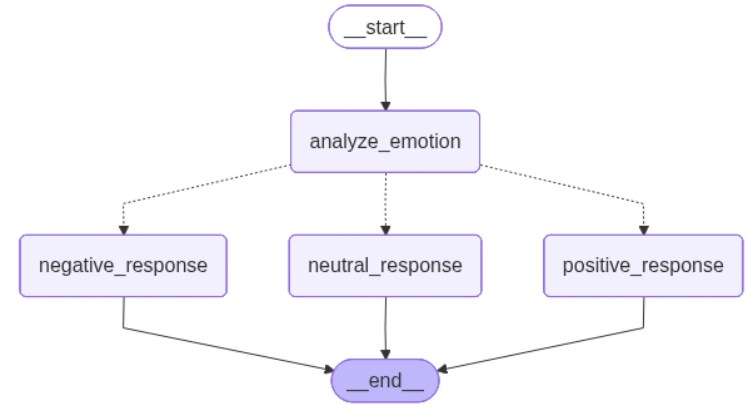

# import

In [1]:
from dotenv import load_dotenv
print(load_dotenv())

from typing import Dict, Any, Literal
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
import random
from IPython.display import Image, display

True


# 그래프 상태 정의

In [2]:
# ① 그래프 상태 정의 - 워크플로우 전체에서 공유되는 데이터 구조
class EmotionBotState(BaseModel):
    user_message: str = Field(default="", description="사용자 입력 메시지")
    emotion: str = Field(default="", description="분석된 감정")
    response: str = Field(default="", description="최종 응답 메시지")
    

# LLM 모델 초기화

In [3]:
# ② LangChain LLM 초기화 - 감정 분석에 사용할 AI 모델 설정
# 감정 분류는 단일 단어만 필요하므로 max_tokens를 10으로 주어서 토큰 수를 제한
llm = ChatOpenAI(model="gpt-4o", max_tokens=10)


# 노드생성

## LLM 기반 감정 분석 노드

In [18]:
# ③ LLM 기반 감정 분석 노드 - 첫 번째 처리 단계
# 응답은 "positive", "negative", "neutral"  3가지중 하나로 답변
def analyze_emotion(state: EmotionBotState) -> Dict[str, Any]:
    message = state.user_message
    
    print(f"🟠 LLM 감정 분석 중: '{message}'")

    messages = [
        SystemMessage(
            content="당신은 감정 분석 전문가입니다. 사용자의 메시지를 분석하여 'positive', 'negative', 'neutral' 중 하나로 감정을 분류해주세요. 답변은 반드시 하나의 단어만 출력하세요."
        ),
        HumanMessage(content=f"다음 메시지의 감정을 분석해주세요: '{message}'"),
    ]
    response = llm.invoke(messages)
    emotion = response.content.strip().lower()
    print(f"✅ 모델 응답: {emotion}")

    # 유효성 검사
    if emotion not in ["positive", "negative", "neutral"]:
        emotion = "neutral" # 기본값
        
    print(f"🟠 LLM 감정 분석 결과: {emotion}")

    return {"emotion": emotion}  # 상태의 emotion 업데이트 -> 이 값에 따라 조건부 라우팅 할거다.

## 응답 생성 노드

In [23]:
# 긍정적 응답 생성
def generate_positive_response(state: EmotionBotState) -> Dict[str, Any]:
    responses = ["정말 좋은 소식이네요!", "기분이 좋으시군요!", "멋지네요!"]
    return {"response": random.choice(responses)}

# 부정적 응답 생성
def generate_negative_response(state: EmotionBotState) -> Dict[str, Any]:
    responses = [
        "힘든 시간이시군요. 괜찮아요.",
        "마음이 아프시겠어요.",
        "더 좋은 날이 올 거예요.",
    ]
    return {"response": random.choice(responses)}

# 중립적 응답 생성
def generate_neutral_response(state: EmotionBotState) -> Dict[str, Any]:
    responses = [
        "감사해요! 더 자세히 말씀해주세요.",
        "이해했어요. 다른 도움이 필요하시면 말씀하세요!",
        "흥미로운 주제네요!",
    ]
    return {"response": random.choice(responses)}


# 조건부 라우팅 함수
- 입력: 상태
- 출력: 다음에 실행할 '노드의 이름(str)'

In [24]:
# ④ 조건부 라우팅 함수 - 감정 분석 결과에 따라 '다음 노드' 결정
def route_by_emotion(
    state: EmotionBotState
) -> Literal["positive_response", "negative_response", "neutral_response"]:
    # typehint 의 Literal 은 '값 그 자체' 로 제한할때 사용.
    
    emotion = state.emotion
    print(f"라우팅: {emotion}")

    if emotion == "positive":
        return "positive_response"
    elif emotion == "negative":
        return "negative_response"
    else:
        return "neutral_response"

    # 위 라우팅 함수에서 리턴된 문자열 값에 의해 그래프 내에서 분기될거다  

# 그래프 생성

In [25]:
# ⑤ 그래프 생성 함수 - 전체 워크플로우 구성
def create_emotion_bot_graph():
    workflow = StateGraph(EmotionBotState)

    # ⑥ 노드 추가 - 각 처리 단계를 그래프에 등록
    # 노드 추가: add_node() 메서드로 각 처리 함수를 그래프에 등록합니다. 
    # 첫 번째 인자는 노드의 고유 식별자(이름)이고, 두 번째 인자는 실제 실행될 함수입니다. 
    # 이 이름은 나중에 에지를 정의할 때 참조됩니다.
    workflow.add_node("analyze_emotion", analyze_emotion)
    workflow.add_node("positive_response", generate_positive_response)
    workflow.add_node("negative_response", generate_negative_response)
    workflow.add_node("neutral_response", generate_neutral_response)


    # ⑦ 시작 엣지 설정 - 워크플로우의 진입점 정의
    # 시작 에지 설정: START는 랭그래프의 특별한 상수로, 워크플로의 시작점을 나타냅니다. 
    # 이 에지는 워크플로가 실행될 때 가장 먼저 analyze_emotion 노드가 실행되도록 보장합니다.
    workflow.add_edge(START, "analyze_emotion")

    # ⑧ 조건부 엣지 설정 - 조건부 라우팅(동적 라우팅) 구현
    #  : add_conditional_edges()는 LangGraph의 핵심 기능으로, 
    #   출발 노드 이름, 라우팅 함수, 가능한 목적지 매핑의 세 가지 인자를 받습니다. 
    #   이를 통해 런타임에 상태 기반으로 다음 실행 경로를 동적으로 결정할 수 있습니다.    
    workflow.add_conditional_edges(
        "analyze_emotion",   # 출발 노드 이름
        route_by_emotion,    # 라우팅 함수
        {                    # 라우팅 함수 결과 -> 분기 목적지 노드 매핑
            "positive_response": "positive_response",
            "negative_response": "negative_response",
            "neutral_response": "neutral_response",
        }
        
    )

    # ⑨ 종료 엣지 설정 - 각 응답 노드에서 워크플로우 종료
    #   END는 워크플로의 종료를 나타내는 특별한 상수입니다. 각 응답 생성 노드에서 END로 향하는 에지를 추가하여, 
    #   응답이 생성되면 워크플로가 종료되도록 합니다.
    workflow.add_edge("positive_response", END)
    workflow.add_edge("negative_response", END)
    workflow.add_edge("neutral_response", END)


    # CompiledGraph 객체 리턴
    return workflow.compile()

# 그래프 생성 & 실행

=== 감정 분석 챗봇 테스트 ===

테스트 1: '오늘 정말 기분이 좋아요!'
🟠 LLM 감정 분석 중: '오늘 정말 기분이 좋아요!'
✅ 모델 응답: positive
🟠 LLM 감정 분석 결과: positive
라우팅: positive
응답: 정말 좋은 소식이네요!

테스트 2: '너무 슬프고 힘들어요...'
🟠 LLM 감정 분석 중: '너무 슬프고 힘들어요...'
✅ 모델 응답: negative
🟠 LLM 감정 분석 결과: negative
라우팅: negative
응답: 마음이 아프시겠어요.

테스트 3: '날씨가 어떤가요?'
🟠 LLM 감정 분석 중: '날씨가 어떤가요?'
✅ 모델 응답: neutral
🟠 LLM 감정 분석 결과: neutral
라우팅: neutral
응답: 이해했어요. 다른 도움이 필요하시면 말씀하세요!



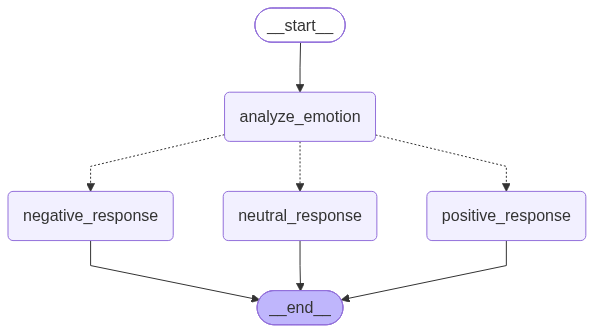

In [26]:
def main():
    print("=== 감정 분석 챗봇 테스트 ===\n")
    # 그래프 생성
    app = create_emotion_bot_graph()

    test_cases = [
        "오늘 정말 기분이 좋아요!",
        "너무 슬프고 힘들어요...",
        "날씨가 어떤가요?",
    ]

    for i, message in enumerate(test_cases, 1):
        print(f"테스트 {i}: '{message}'")
        state = EmotionBotState(user_message=message)  # 초기 상태 준비
        result = app.invoke(state)
        print(f"응답: {result['response']}\n")
        
    # 그래프 시각화
    display(Image(app.get_graph().draw_mermaid_png()))


if __name__ == "__main__":
    main()
